<a href="https://colab.research.google.com/github/vennelanalajam/myproject/blob/main/HousePricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Title : HousePricePrediction

# Problem Understanding :

The objective of this project is to analyze housing data and build a machine learning model to predict house prices based on various features.

The dataset contains 79 explanatory variables describing different aspects of residential homes such as area, quality, location, and amenities.

# Business Objective :
- Help buyers understand fair pricing
- Help sellers price properties correctly
- Assist real estate companies in decision-making
- Perform detailed Exploratory Data Analysis (EDA)
- Build a robust regression model to predict house prices
- Identify key factors affecting house prices
- Provide business recommendations for buyers

# Target Variable: SalePrice

# ML Objective :
- Build a regression model to predict SalePrice
- Identify key factors influencing house prices

# Step 1: Problem Understanding :

This project aims to analyze housing data and build a machine learning model to predict house prices.

The dataset contains multiple features such as area, quality, location, and construction details.

# Step 2 : Import Libraries :
### Explanation:
- Pandas, NumPy → data handling
- Seaborn, Matplotlib → visualization
- Sklearn → machine learning models and evaluation

In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import warnings
warnings.filterwarnings("ignore")

# Step 3 : Load Dataset :
### Explanation:
Dataset is loaded and previewed to understand structure and columns.

In [2]:
# Load dataset

df = pd.read_csv("/content/data.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# Step 4:  Data Understanding :
### Key Observations:
- Dataset contains both numerical and categorical features
- Target variable: SalePrice
- Missing values present in multiple columns

In [3]:
# Basic Checks
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [5]:
df.shape

(1460, 81)

In [6]:
df.dtypes

,0
Id,int64
MSSubClass,int64
MSZoning,object
LotFrontage,float64
LotArea,int64
...,...
MoSold,int64
YrSold,int64
SaleType,object
SaleCondition,object


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [32]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MSSubClass,1460.0,56.897260,42.300571,20.0,20.0,50.0,70.0,190.0
MSZoning,1460.0,3.028767,0.632017,0.0,3.0,3.0,3.0,4.0
LotFrontage,1460.0,69.863699,22.027677,21.0,60.0,69.0,79.0,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.5,9478.5,11601.5,215245.0
Street,1460.0,0.995890,0.063996,0.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...
SaleType,1460.0,7.513014,1.552100,0.0,8.0,8.0,8.0,8.0
SaleCondition,1460.0,3.770548,1.100854,0.0,4.0,4.0,4.0,5.0
SalePrice,1460.0,180921.195890,79442.502883,34900.0,129975.0,163000.0,214000.0,755000.0
TotalSF,1460.0,2567.048630,821.714421,334.0,2009.5,2474.0,3004.0,11752.0


In [36]:
df.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
MSSubClass,1460.0,56.897260,42.300571,20.0,20.0,50.0,70.0,190.0
MSZoning,1460.0,3.028767,0.632017,0.0,3.0,3.0,3.0,4.0
LotFrontage,1460.0,69.863699,22.027677,21.0,60.0,69.0,79.0,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.5,9478.5,11601.5,215245.0
Street,1460.0,0.995890,0.063996,0.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...
SaleType,1460.0,7.513014,1.552100,0.0,8.0,8.0,8.0,8.0
SaleCondition,1460.0,3.770548,1.100854,0.0,4.0,4.0,4.0,5.0
SalePrice,1460.0,180921.195890,79442.502883,34900.0,129975.0,163000.0,214000.0,755000.0
TotalSF,1460.0,2567.048630,821.714421,334.0,2009.5,2474.0,3004.0,11752.0


In [10]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [11]:
df.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [12]:
df.duplicated().sum()

np.int64(0)

#Step 5 : Data Cleaning :
### Explanation:
- Numerical → median (robust to outliers)
- Categorical → mode (most frequent value)

In [13]:
# Drop unnecessary column
if 'Id' in df.columns:
    df.drop('Id', axis=1, inplace=True)

# Missing values
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

# Fill numerical with median
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical with mode
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [14]:
# check if there is any nulls values are there
df.isnull().sum()

,0
MSSubClass,0
MSZoning,0
LotFrontage,0
LotArea,0
Street,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1460 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          1460 non-null   object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

#Step 6 : Exploratory Data Analysis (EDA) :
Target Distribution

### Insight:
- Data is right-skewed
- High-value houses are fewer but impact model

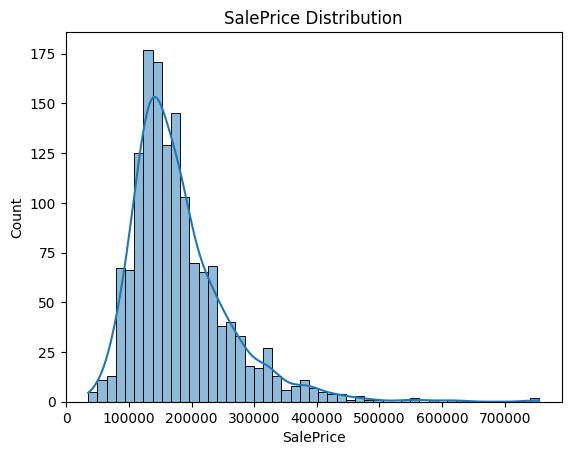

In [16]:
sns.histplot(df['SalePrice'], kde=True)
plt.title("SalePrice Distribution")
plt.show()

#Correlation Analysis:
### Fix for Correlation Data set

The dataset contains categorical variables (e.g., 'RL', 'RM'), which cannot be used directly in correlation calculation.

To resolve this:
- Only numerical columns were selected
- Correlation matrix was computed on numerical features

This ensures valid statistical relationships are analyzed.

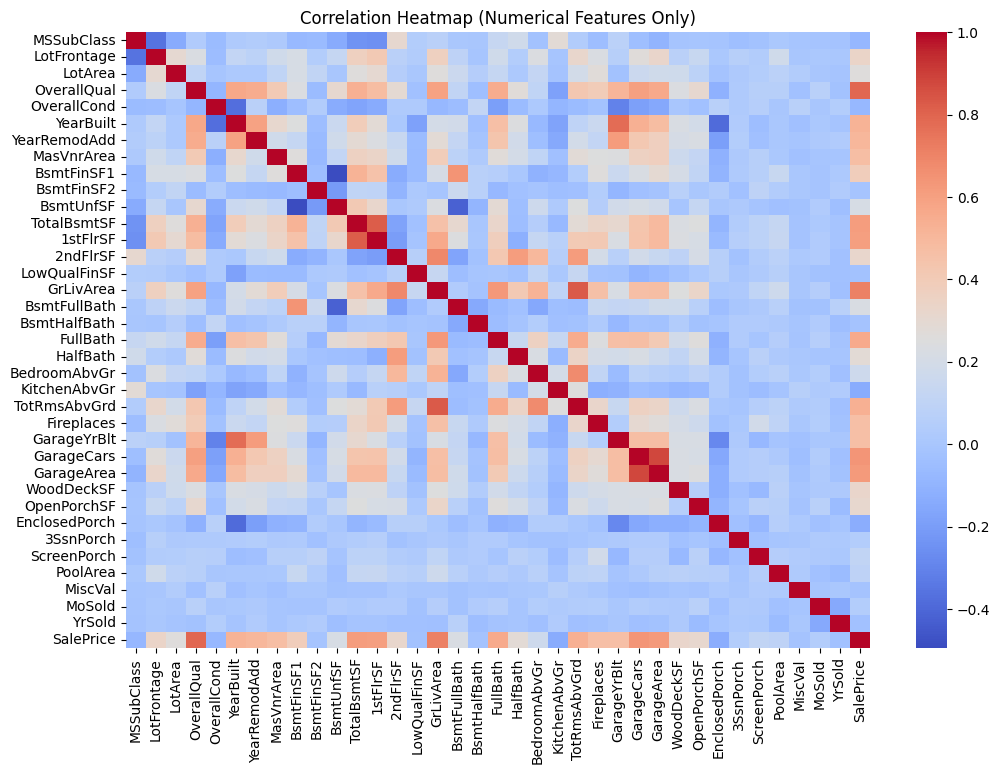

In [18]:
plt.figure(figsize=(12,8))

num_df = df.select_dtypes(include=['int64', 'float64'])
corr = num_df.corr()

sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Heatmap (Numerical Features Only)")
plt.show()

# Top Features :
### Insight:
- Larger area → higher price
- Better quality → higher price

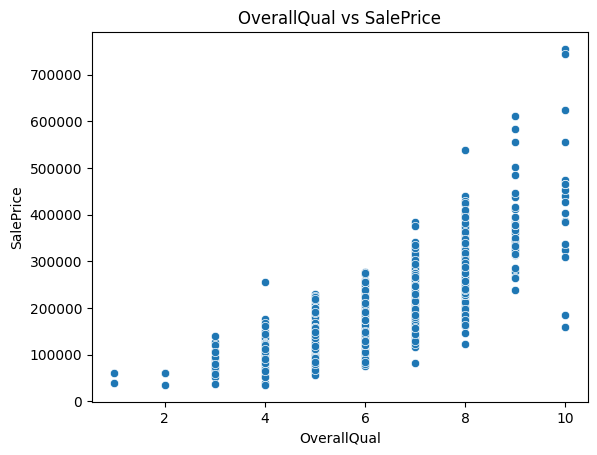

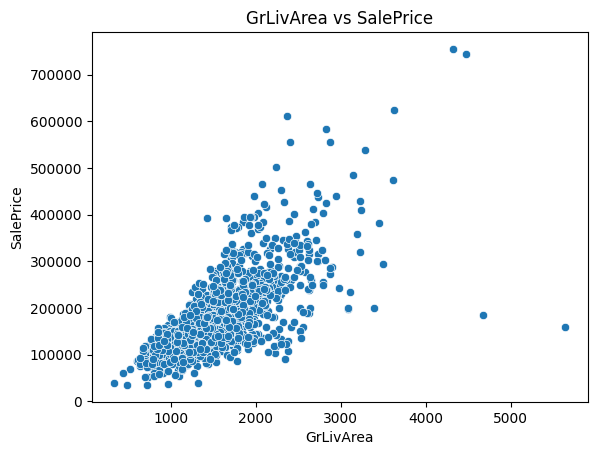

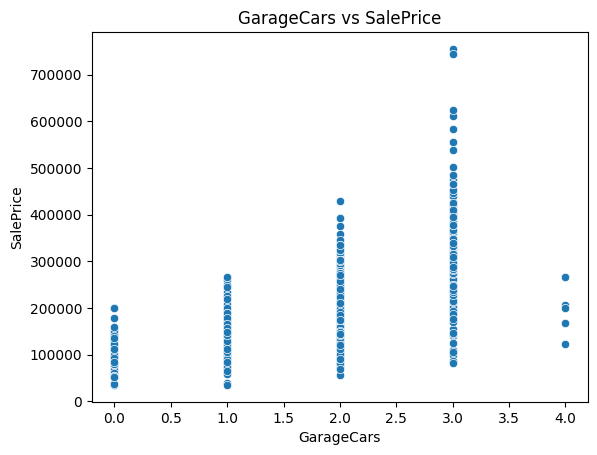

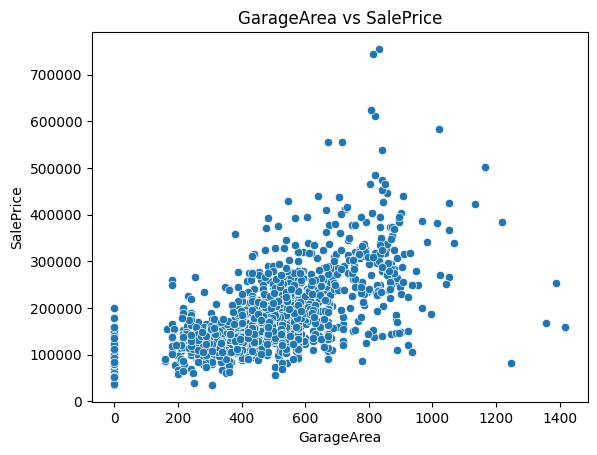

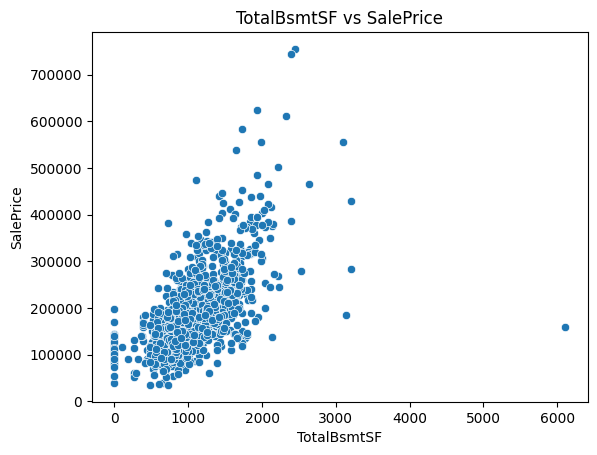

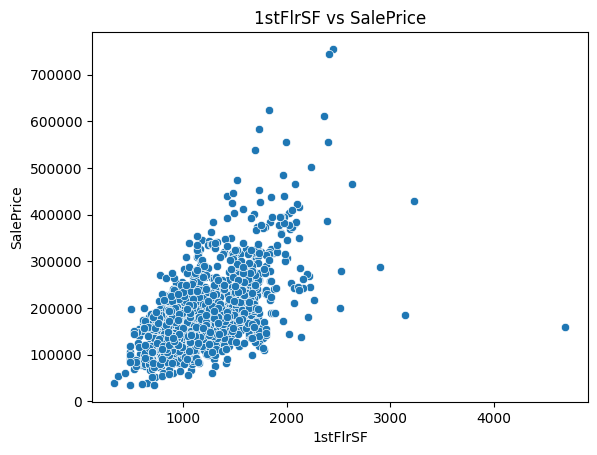

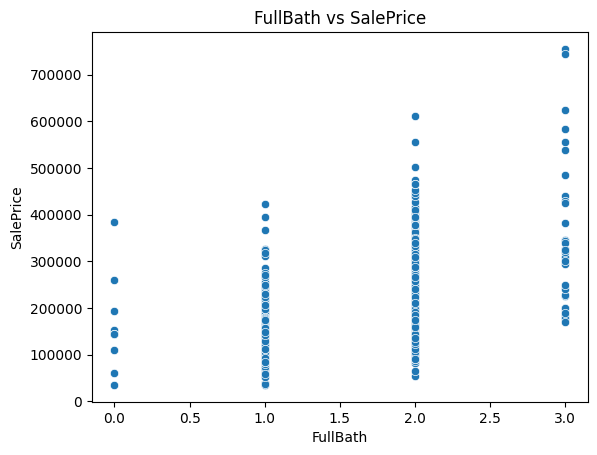

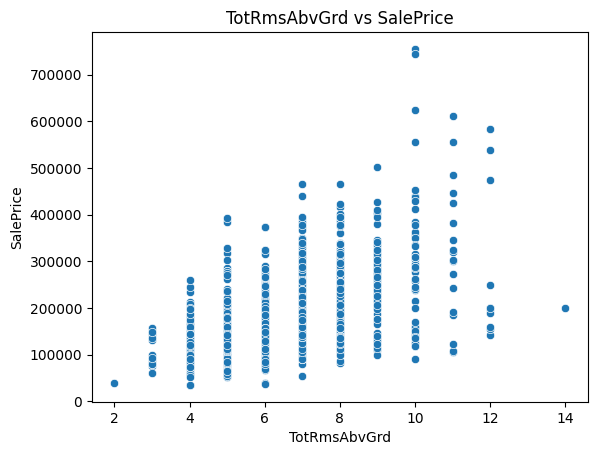

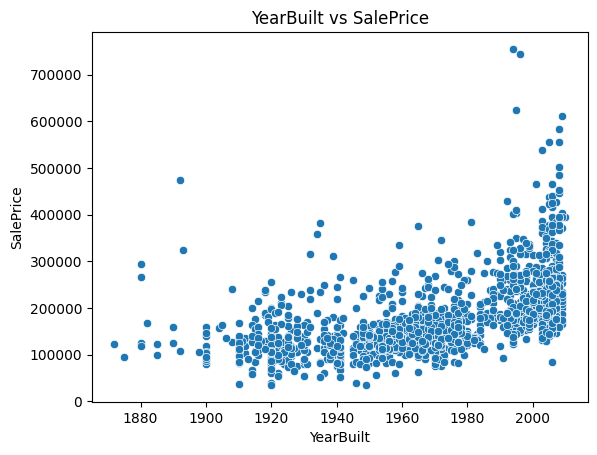

In [19]:
top_features = corr['SalePrice'].abs().sort_values(ascending=False)[1:10]

for col in top_features.index:
    sns.scatterplot(x=df[col], y=df['SalePrice'])
    plt.title(f"{col} vs SalePrice")
    plt.show()

#Step 7: Feature Engineering :
### Explanation:
- Combined area gives better representation
- Age impacts depreciation

In [20]:
# Create new features

df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
df['HouseAge'] = df['YrSold'] - df['YearBuilt']

df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,TotalSF,HouseAge
0,60,RL,65.0,8450,Pave,Grvl,Reg,Lvl,AllPub,Inside,...,MnPrv,Shed,0,2,2008,WD,Normal,208500,2566,5
1,20,RL,80.0,9600,Pave,Grvl,Reg,Lvl,AllPub,FR2,...,MnPrv,Shed,0,5,2007,WD,Normal,181500,2524,31
2,60,RL,68.0,11250,Pave,Grvl,IR1,Lvl,AllPub,Inside,...,MnPrv,Shed,0,9,2008,WD,Normal,223500,2706,7
3,70,RL,60.0,9550,Pave,Grvl,IR1,Lvl,AllPub,Corner,...,MnPrv,Shed,0,2,2006,WD,Abnorml,140000,2473,91
4,60,RL,84.0,14260,Pave,Grvl,IR1,Lvl,AllPub,FR2,...,MnPrv,Shed,0,12,2008,WD,Normal,250000,3343,8


#Step 8 : Data Preprocessing :
### Explanation:
- Encoding → converts text to numbers
- Scaling → improves model performance

In [22]:
# Encoding categorical variables
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Split data
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Step 9 : Model Building :
🔸 Linear Regression

In [23]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("LR RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("LR R2:", r2_score(y_test, y_pred_lr))

LR RMSE: 35312.138344719
LR R2: 0.837432322851122


🔸 Random Forest

In [24]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RF RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("RF R2:", r2_score(y_test, y_pred_rf))

RF RMSE: 29684.51738007896
RF R2: 0.8851195440341834


🔸 Gradient Boosting

In [25]:
gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("GB RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb)))
print("GB R2:", r2_score(y_test, y_pred_gb))

GB RMSE: 27507.710800911995
GB R2: 0.9013504598021393


# Step 10 : Model Comparison :

In [26]:
comparison = pd.DataFrame({
    'Model': ['Linear', 'Random Forest', 'Gradient Boosting'],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_gb))
    ],
    'R2 Score': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_gb)
    ]
})

comparison

,Model,RMSE,R2 Score
0,Linear,35312.138345,0.837432
1,Random Forest,29684.517380,0.885120
2,Gradient Boosting,27507.710801,0.901350


### Insight:
Gradient Boosting and Random Forest outperform Linear Regression.

#Step 11 : Hyperparameter Tuning :
### Explanation:
Tuning improves model accuracy and reduces overfitting.

In [27]:
params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20]
}

grid = GridSearchCV(RandomForestRegressor(), params, cv=3)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': 10, 'n_estimators': 100}


#Step 12 : Final Model Evaluation :     


In [28]:
best_model = grid.best_estimator_

y_pred_final = best_model.predict(X_test)

print("Final RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_final)))
print("Final R2:", r2_score(y_test, y_pred_final))

Final RMSE: 29515.570727515413
Final R2: 0.886423485541635


### Conclusion:
Final model shows strong predictive performance and can be used in real-world scenarios.

#Step 13 :  Business Insights & Recommendations :    


## Key Insights:
- Overall quality is the strongest price driver
- Living area significantly impacts price
- New houses have higher value
- Location plays a major role

## Recommendations:

### For Buyers:
- Focus on quality rather than just size
- Prefer newer houses
- Invest in developing areas

### For Sellers:
- Improve house condition before selling
- Highlight key features like area and quality

#Step 14 :  Challenges Faced :     
## Challenges:

1. Missing values in multiple columns
2. Large number of categorical features
3. Feature engineering complexity
4. Risk of overfitting in tree models

## Solutions:
- Used median/mode imputation
- Applied encoding techniques
- Used GridSearchCV for tuning